# First Experiment: Multiclass Classification

In this jupyter notebook, 3 classification models will be tested on the dataset: SVM, Random Forest, KNN. Before doing this task, a cross-validation was done in order to get the best parameters to classify pigments and dyes. 

SVM model:
- Kernel function = Gaussian (rbf)
- Box constraint level (C) = 10
- Kernel scale ($\gamma$) = Automatic (scale)
- Multiclass coding = One-vs-One
- Data standardization = Yes

RF model:
- Number of estimators (n_estimators) = 100
- Maximum number of features (max_features) = sqrt

KNN model:
- Number of neighbors (n_neighbors) = 5
- Distance metric (metric) = Manhattan
- Weight function (weights) = Distance
- Data standardization = Yes (StandardScaler)

## Import all libraries use

In [19]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import joblib 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Import dataset

In [20]:
def load_data():
    data = loadmat('dataset.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (43507, 121)
Train y: (43507,)
Test X: (10809, 121)
Test y: (10809,)


Now, lets visualize the dataset in a table. Also, lets see how many training pixels and test pixels we have got

In [21]:
df_train = pd.DataFrame(X_train)
df_train["label"] = y_train

print("Primeras filas del DataFrame:")
print(df_train.head())

Primeras filas del DataFrame:
            0           1           2  ...       119       120  label
0  160.947632  228.826462  285.927002  ...  0.000000  0.000000     62
1  158.270508  217.518707  277.381256  ...  0.000000  0.000000     62
2  148.375381  208.553558  262.519989  ...  0.000000  0.018474     62
3  154.939667  209.060791  268.925537  ...  0.586883  0.000000     62
4  156.129364  223.788437  290.352386  ...  0.000000  0.000000     62

[5 rows x 122 columns]


In [22]:
print("Distribución de clases:")
print(df_train["label"].value_counts())

Distribución de clases:
label
109    5104
62     4788
85     4724
63     4682
64     4596
65     4577
88     4221
12     4000
87     3661
117    3154
Name: count, dtype: int64


In [23]:
df_test = pd.DataFrame(X_test)
df_test["label"] = y_test

print("Primeras filas del DataFrame de TEST:")
print(df_test.head())

Primeras filas del DataFrame de TEST:
            0           1           2  ...       119       120  label
0  213.805298  299.587830  386.809052  ...  0.028036  0.085361     62
1  214.336914  282.420776  371.378326  ...  0.000000  0.000000     62
2  214.160767  296.567749  379.936768  ...  0.000000  0.000000     62
3  212.476517  296.685669  378.694519  ...  0.000000  0.221686     62
4  206.896057  284.726196  366.295471  ...  0.000000  0.062349     62

[5 rows x 122 columns]


In [24]:
print("Distribución de clases:")
print(df_test["label"].value_counts())

Distribución de clases:
label
88     2975
109    2094
87     1001
12     1000
62      856
63      803
64      792
117     590
65      364
85      334
Name: count, dtype: int64


The training set is aproximately balanced, but the test set is not. The test set is intentionally unbalanced because historical documents often contain uneven amounts of material across classes. Therefore, this distribution better reflects realistic classification scenarios and provides a more representative evaluation of model performance.

## Labels of pigments and dyes

In [25]:
# Each label correspond to a material. I will name it in spanish 
class_names = {
    12: "Sustrato Algodón-lino",
    62: "Esmalte-GA",
    63: "Lapislázuli-GA",
    64: "BlancoPb-GA",
    65: "Calcita-GA",
    85: "Esmalte-CH",
    87: "BlancoPb-CH",
    88: "Calcita-CH",
    109: "Imperial Yellow Ink-GA",
    117: "Azafrán-GA",
}

## SVM classification

In [26]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7410491257285595

Classification report:
              precision    recall  f1-score   support

          12       0.39      0.97      0.56      1000
          62       1.00      0.94      0.97       856
          63       0.72      0.59      0.65       803
          64       0.86      0.72      0.78       792
          65       0.94      0.87      0.90       364
          85       0.98      0.99      0.98       334
          87       1.00      0.52      0.69      1001
          88       1.00      0.62      0.76      2975
         109       0.78      0.81      0.80      2094
         117       0.50      0.82      0.62       590

    accuracy                           0.74     10809
   macro avg       0.82      0.79      0.77     10809
weighted avg       0.84      0.74      0.76     10809



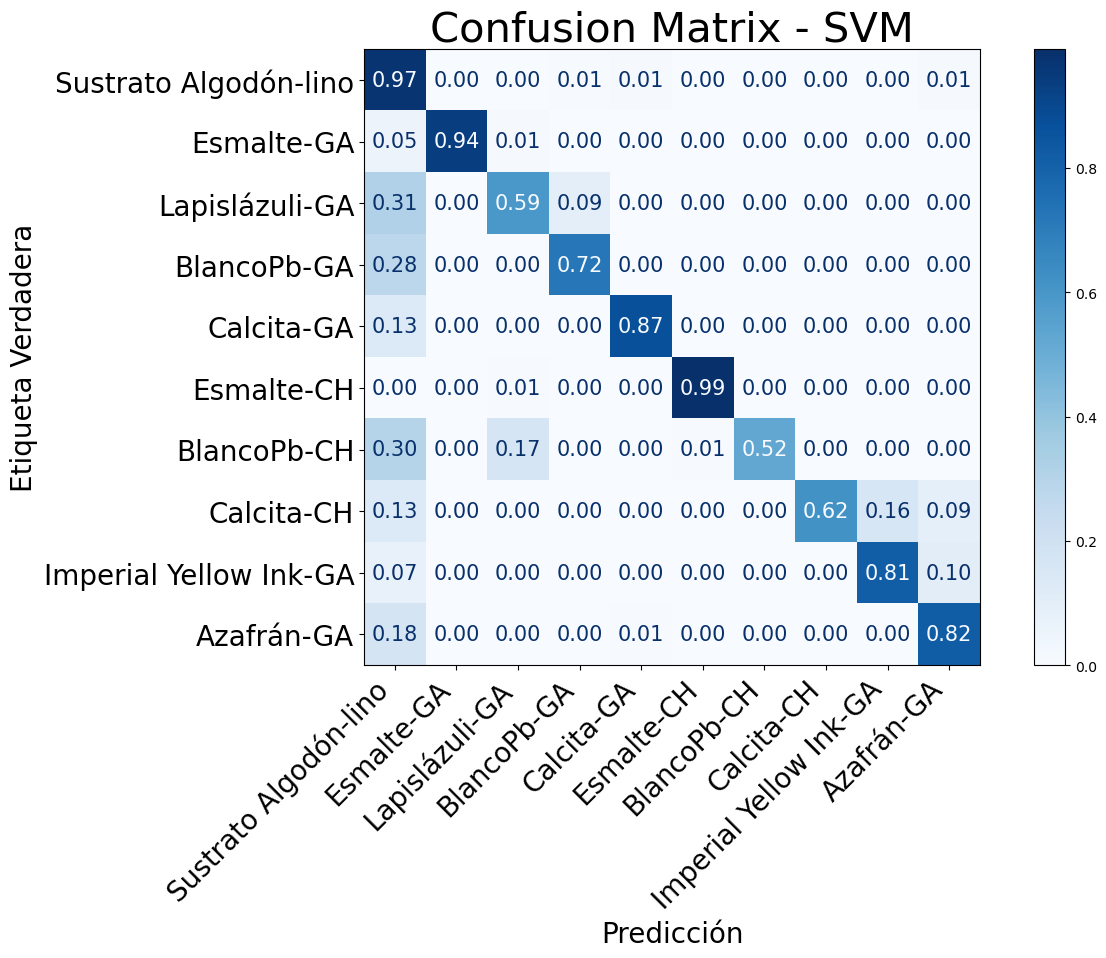

In [28]:
labels = np.unique(y_test)
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14,8))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - SVM", fontsize=30)

for text in ax.texts:
    text.set_fontsize(15)

ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta Verdadera", fontsize=20)

plt.show()

## Random Forest Classification

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.723563696919234

Classification report:
              precision    recall  f1-score   support

          12       0.39      0.97      0.56      1000
          62       1.00      0.96      0.98       856
          63       0.56      0.54      0.55       803
          64       0.88      0.66      0.76       792
          65       0.94      0.91      0.92       364
          85       0.99      1.00      0.99       334
          87       1.00      0.39      0.56      1001
          88       1.00      0.61      0.76      2975
         109       0.69      0.83      0.75      2094
         117       0.65      0.80      0.72       590

    accuracy                           0.72     10809
   macro avg       0.81      0.77      0.75     10809
weighted avg       0.82      0.72      0.73     10809



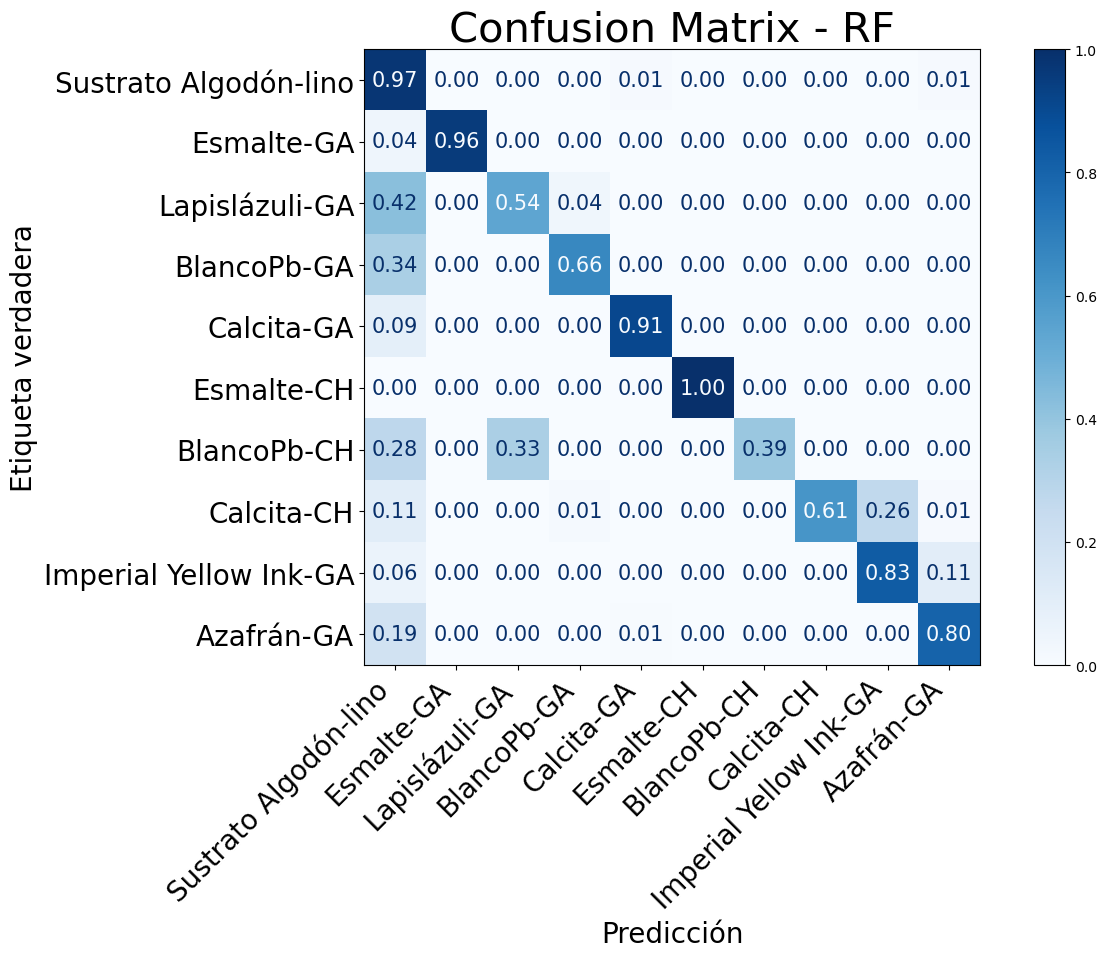

In [33]:
labels = list(class_names.keys())
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14,8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta verdadera", fontsize=20)

plt.title("Confusion Matrix - RF", fontsize=30)

for text in ax.texts:
    text.set_fontsize(15)


ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)
plt.show()

## KNN classification

In [34]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        metric="manhattan",
        weights="distance"
    ))
])

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification report:")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.7288370802109353

Classification report:
              precision    recall  f1-score   support

          12       0.38      0.97      0.54      1000
          62       1.00      0.93      0.96       856
          63       0.94      0.26      0.41       803
          64       0.86      0.61      0.71       792
          65       0.92      0.92      0.92       364
          85       0.95      1.00      0.98       334
          87       0.95      0.85      0.90      1001
          88       1.00      0.66      0.80      2975
         109       0.79      0.69      0.73      2094
         117       0.40      0.83      0.54       590

    accuracy                           0.73     10809
   macro avg       0.82      0.77      0.75     10809
weighted avg       0.84      0.73      0.74     10809



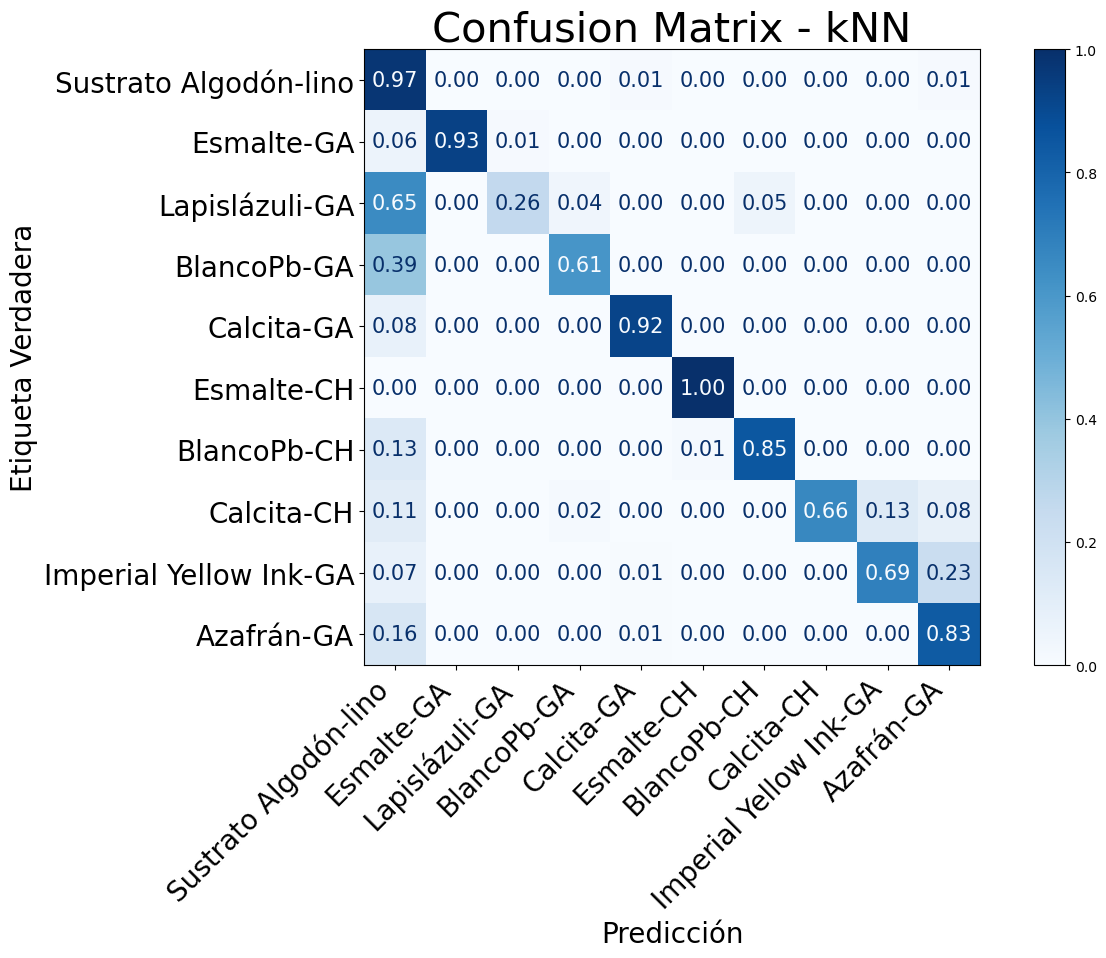

In [36]:
labels = list(class_names.keys())
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14,8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta Verdadera", fontsize=20)

for text in ax.texts:
    text.set_fontsize(15)

ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

plt.title("Confusion Matrix - kNN", fontsize=30)
plt.show()